# Week 2 — Discrete dynamics and the modeling process

Companion notebook of the second lecture. We walk the **modeling process** end to end on a real dataset, meet **equilibria and stability**, solve a **two-variable system**, end with the most famous difference equation of all — the **logistic map** and its route to chaos — and close by simplifying this week's case, the **2021 C hornet model**.

**How to run**: Anaconda locally (`jupyter lab`), or Colab/Binder from the [course repository](https://github.com/liwt31/MathModel). Run cells in order with `Shift+Enter`.

**Note.** The exercises here and on the slides are **practice for yourself** — they are **not** the graded assignments. Problem sets are released separately on Blackboard, with due dates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:                                  # optional style file, ships with the course
    plt.style.use("mm.mplstyle")
except OSError:
    pass

## 1. The modeling process

Every model in this course (and every MCM/ICM paper) follows the same loop:

1. **Identify the problem** — what is asked, in measurable terms?
2. **Assumptions** — decide the variables, and what to ignore.
3. **Build the model** — a mathematical relation between the variables.
4. **Solve / compute** — with pen and paper, or code.
5. **Compare with data** — does the model reproduce reality?
6. **Report / refine** — state results honestly; if they fail, go back to step 2.

We now run this loop once, slowly, on a classic dataset.

## 2. The question and the data

**Question.** Yeast is grown in a culture; biomass $p_n$ is measured every hour. **How does the population grow, and what happens in the long run?**

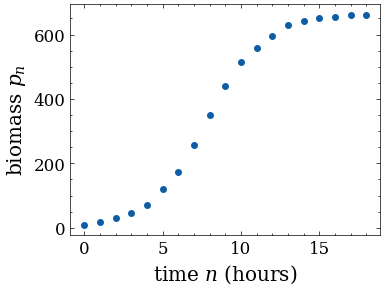

In [2]:
time = np.arange(19)
observed = np.array([9.6, 18.3, 29.0, 47.2, 71.1, 119.1, 174.6, 257.3,
                     350.7, 441.0, 513.3, 559.7, 594.8, 629.4, 640.8,
                     651.1, 655.9, 659.6, 661.8])

plt.plot(time, observed, "o", ms=4)
plt.xlabel("time $n$ (hours)")
plt.ylabel("biomass $p_n$")
plt.show()

Clearly not exponential forever — the growth **slows down** as $p_n$ gets large (food runs out). Let us model the *change* from hour to hour.

## 3. Model the change (assumptions → model)

**Assumption.** The change over one hour, $p_{n+1}-p_n$, depends only on the current biomass $p_n$ — small populations grow fast, near capacity growth stops. Test it on the first eight hours:

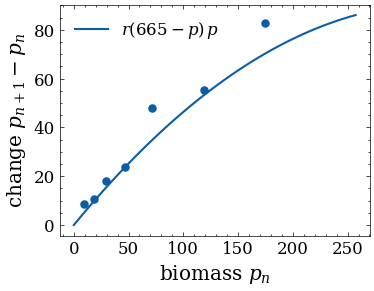

In [3]:
init = observed[:8]
change = init[1:] - init[:-1]

plt.scatter(init[:-1], change, s=26)
xs = np.linspace(0, init.max(), 50)
r, M = 0.00082, 665.0
plt.plot(xs, r * (M - xs) * xs, "-", lw=1.5, label=r"$r(665-p)\,p$")
plt.xlabel(r"biomass $p_n$")
plt.ylabel(r"change $p_{n+1}-p_n$")
plt.legend(frameon=False)
plt.show()

The changes sit close to a **parabola**: growth is proportional to what is present **and** to what is still missing:

$$p_{n+1} = p_n + r\,(M - p_n)\,p_n, \qquad r = 0.00082,\;\; M = 665.$$

This is a **difference equation** — the model of the whole process. Simulate it and compare:

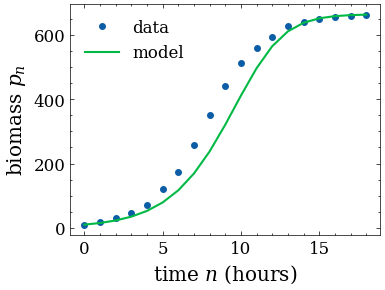

In [4]:
p = np.zeros(len(time))
p[0] = observed[0]
for n in range(len(time) - 1):
    p[n + 1] = p[n] + r * (M - p[n]) * p[n]

plt.plot(time, observed, "o", ms=4, label="data")
plt.plot(time, p, "-", lw=1.5, label="model")
plt.xlabel("time $n$ (hours)")
plt.ylabel("biomass $p_n$")
plt.legend(frameon=False)
plt.show()

## 4. Equilibria and stability

An **equilibrium** is a value that the model never leaves: $p_{n+1} = p_n$ means

$$0 = r\,(M - p^*)\,p^* \quad\Longrightarrow\quad p^* = 0 \;\; \text{or} \;\; p^* = M = 665.$$

Which of these will the model actually settle at? Test numerically from different starts:

In [5]:
def run(p0, weeks=30):
    ps = [p0]
    for _ in range(weeks):
        ps.append(ps[-1] + r * (M - ps[-1]) * ps[-1])
    return np.array(ps)

for p0 in [1.0, 300.0, 660.0, 670.0]:
    ps = run(p0)
    print(f"start p0 = {p0:>6.1f}  ->  after 30 steps: {ps[-1]:.4f}")

start p0 =    1.0  ->  after 30 steps: 664.9941
start p0 =  300.0  ->  after 30 steps: 665.0000
start p0 =  660.0  ->  after 30 steps: 665.0000
start p0 =  670.0  ->  after 30 steps: 665.0000


Every start near the culture ends at $p^* = 665$: that equilibrium is **stable**. The equilibrium $p^*=0$ is **unstable** — a tiny population still grows away from it. Stability is exactly the kind of long-run question models are built to answer.

## 5. Solve analytically, then fit

**Honest answer first**: our difference equation has **no simple closed-form solution** — the quadratic feedback forbids exact formulas, so simulation is the honest tool.

But its **continuous cousin**, the logistic *differential* equation $\frac{\dx P}{\dx t} = rP(M-P)$, *can* be solved by hand: separate the variables, integrate with partial fractions, and

$$P(t) = \frac{M\,P_0}{P_0 + (M - P_0)\,e^{-rMt}}.$$

We use this curve as a **benchmark shape** for the data. Its key property: $\ln\frac{P}{M - P}$ is **linear in time** — so a straight-line fit determines the constants:

In [6]:
y = np.log(observed / (M - observed))
slope, intercept = np.polyfit(time, y, 1)

print(f"slope = {slope:.5f}   ->  r*M = {slope:.5f}")
print(f"intercept = {intercept:.4f}   ->  P0 = {M / (1 + np.exp(-intercept)):.2f}")

slope = 0.53067   ->  r*M = 0.53067
intercept = -4.1636   ->  P0 = 10.18


(`np.polyfit` is the one-liner to remember; Week 3 is entirely about such fits.)

The fitted **logistic curve** predicts all 19 hours — compare with the simulation, and look at the relative error:

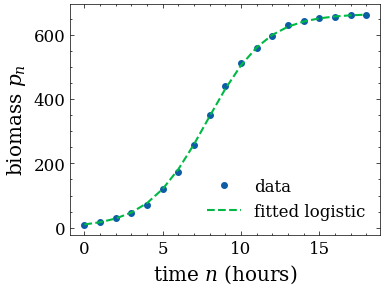

In [7]:
r_fit = slope / M
P0 = M / (1 + np.exp(-intercept))
P_pred = M * P0 / (P0 + (M - P0) * np.exp(-r_fit * M * time))

plt.plot(time, observed, "o", ms=4, label="data")
plt.plot(time, P_pred, "--", lw=1.5, label="fitted logistic")
plt.xlabel("time $n$ (hours)")
plt.ylabel("biomass $p_n$")
plt.legend(frameon=False)
plt.show()

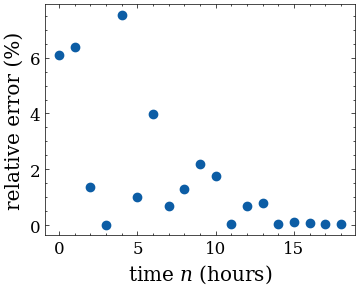

In [8]:
plt.scatter(time, np.abs((observed - P_pred) / observed) * 100)
plt.xlabel("time $n$ (hours)")
plt.ylabel("relative error (%)")
plt.show()

A few percent for most hours — a full modeling loop, closed. (Where the error peaks, ask: which assumption would you revisit?)

## 6. More linear rules: savings, mortgage, prescription, annuity

All four fit $a_{n+1} = r\,a_n + b$. The savings account and mortgage we can simply \**iterate**:

In [9]:
# savings: r = 1.01, b = 0
a, traj_s = 1000.0, [1000.0]
for n in range(12):
    a = 1.01 * a
    traj_s.append(a)

# mortgage: r = 1.01, b = -880.87
b, traj_m = 80000.0, [80000.0]
months = 0
while b > 0 and months < 500:
    b = 1.01 * b - 880.87
    traj_m.append(b)
    months += 1

print(f"savings after 12 months: {traj_s[-1]:,.2f}")
print(f"mortgage b_72 = {traj_m[72]:,.2f}   (deck's value: 71,532.11)")
print(f"loan fully paid after {months} months")

savings after 12 months: 1,126.83
mortgage b_72 = 71,532.11   (deck's value: 71,532.11)
loan fully paid after 240 months


An **equilibrium value** of $a_{n+1} = r a_n + b$ solves $a = ra + b$, so $a^* = b/(1-r)$ — and the solution is $a_n = r^n c + a^*$. Hence the sign of $r$ decides everything: $|r|<1$ stable, $|r|>1$ unstable. Two contrasting examples:

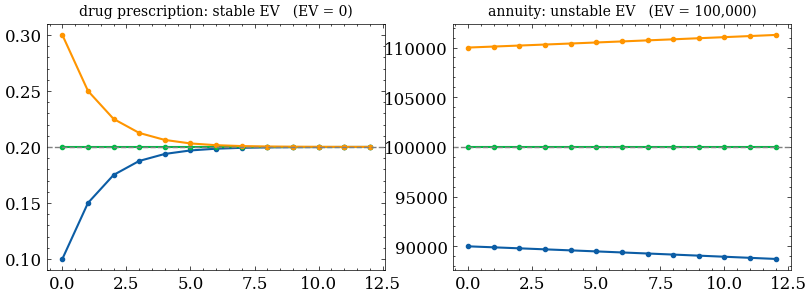

In [10]:
def linear_run(r, b, starts, steps=12):
    out = []
    for a0 in starts:
        a, traj = a0, [a0]
        for _ in range(steps):
            a = r * a + b
            traj.append(a)
        out.append(traj)
    return out

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
for ax, (r, b, starts, title) in zip(axes, [
        (0.5, 0.1, [0.1, 0.2, 0.3], "drug prescription: stable EV"),
        (1.01, -1000, [90000, 100000, 110000], "annuity: unstable EV")]):
    for traj in linear_run(r, b, starts):
        ax.plot(traj, "o-", ms=3)
    star = b / (1 - r)
    ax.axhline(star, ls="--", lw=1, color="gray")
    ax.set_title(f"{title}   (EV = {star:,.0f})", fontsize=10)
plt.show()

The prescription converges to $0.2$ from every start (**stable** — good for dosing); the annuity runs away from \$100,000 (**unstable** — deposit less and you eventually go broke).

## 7. A system: the car rental company

Two variables now. A company operates in Orlando and Tampa; weekly, 60% of Orlando cars **stay** and 40% move to Tampa, while 30% of Tampa cars stay and 70% move. State vector $v_n = (\text{Orlando}, \text{Tampa})$:

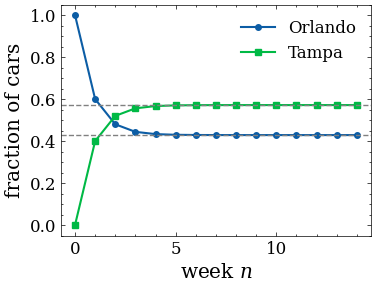

In [11]:
T = np.array([[0.6, 0.4],     # transition matrix: row = now, column = next
              [0.3, 0.7]])
v = np.array([1.0, 0.0])      # all cars start in Orlando

traj = [v.copy()]
for n in range(14):
    v = v @ T
    traj.append(v.copy())
traj = np.array(traj)

plt.plot(traj[:, 0], "o-", ms=4, label="Orlando")
plt.plot(traj[:, 1], "s-", ms=4, label="Tampa")
plt.axhline(3/7, ls="--", lw=1, color="gray")
plt.axhline(4/7, ls="--", lw=1, color="gray")
plt.xlabel("week $n$")
plt.ylabel("fraction of cars")
plt.legend(frameon=False)
plt.show()

Whatever the start, the split converges to **$3/7$ vs $4/7$**. At equilibrium $v^* = v^* T$ — solve it and check:

In [12]:
lam, vec = np.linalg.eig(T.T)          # left eigenvector for eigenvalue 1
k = np.argmin(np.abs(lam - 1))
v_star = np.real(vec[:, k]); v_star = v_star / v_star.sum()
print("equilibrium:", v_star.round(4), "   (3/7 =", round(3/7, 4), ")")

equilibrium: [0.4286 0.5714]    (3/7 = 0.4286 )


The matrix view ($v_{n+1} = v_n T$) turns a loop into linear algebra — eigenvalues then tell you *whether* and *how fast* things converge. This is the tool behind Google's original PageRank.

## 8. Competition: owls vs hawks

Alone, each species grows unconstrained ($\Delta O_n = k_1 O_n$); competition diminishes growth proportionally to the **product** of the populations. With $k_1=0.2$, $k_2=0.3$, $k_3=0.001$, $k_4=0.002$:

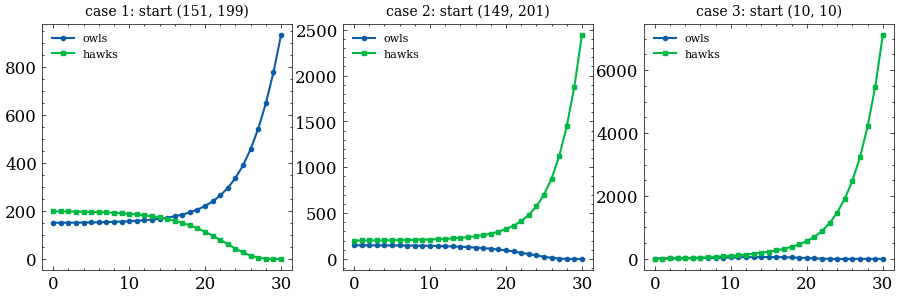

In [13]:
def hunter(O0, H0, days=30):
    O, H = O0, H0
    Os, Hs = [O], [H]
    for _ in range(days):
        O, H = O + 0.2 * O - 0.001 * O * H, H + 0.3 * H - 0.002 * O * H
        Os.append(O); Hs.append(H)
    return np.array(Os), np.array(Hs)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, (O0, H0, tag) in zip(axes, [(151, 199, "case 1"), (149, 201, "case 2"), (10, 10, "case 3")]):
    Os, Hs = hunter(O0, H0)
    ax.plot(Os, "o-", ms=3, label="owls")
    ax.plot(Hs, "s-", ms=3, label="hawks")
    ax.set_title(f"{tag}: start ({O0}, {H0})", fontsize=10)
    ax.legend(frameon=False, fontsize=8)
plt.show()

Equilibria: $(0,0)$ and $(150,200)$ — both **unstable**. Starting one owl away from $(150,200)$ sends the system to opposite fates: hawks die out in case 1, owls die out in cases 2 and 3. Coexistence is impossible in this model, and the outcome is **sensitive to initial conditions**.

## 9. Beyond equilibrium: the logistic map

Rescale the yeast model and you get the most-studied difference equation in mathematics,

$$x_{n+1} = \mu\, x_n (1 - x_n), \qquad x_n \in [0,1].$$

Same idea as before, one parameter $\mu$. Iterate it and draw the **cobweb**:

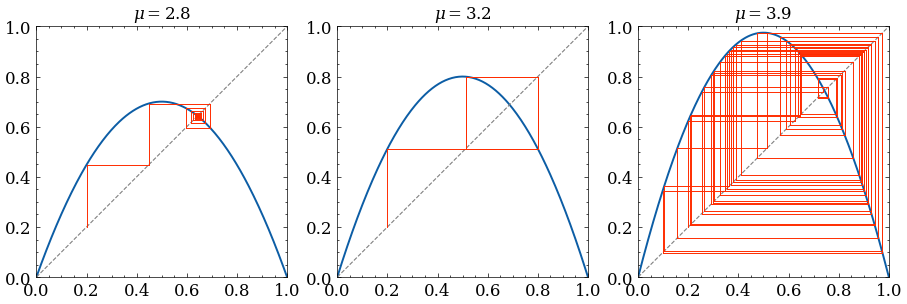

In [14]:
def cobweb(mu, x0=0.2, iters=60):
    xs = np.linspace(0, 1, 300)
    plt.plot(xs, mu * xs * (1 - xs), lw=1.4)
    plt.plot(xs, xs, color="gray", lw=0.8, ls="--")
    x = x0
    for _ in range(iters):
        y = mu * x * (1 - x)
        plt.plot([x, x], [x, y], color="#FF2C00", lw=0.7)
        plt.plot([x, y], [y, y], color="#FF2C00", lw=0.7)
        x = y
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.title(rf"$\mu = {mu}$")
    plt.gca().set_aspect("equal")

plt.figure(figsize=(11, 3.6))
for i, mu in enumerate([2.8, 3.2, 3.9]):
    plt.subplot(1, 3, i + 1)
    cobweb(mu)
plt.show()

Same equation, three fates: **settle down** ($\mu=2.8$), **bounce in a 2-cycle** ($\mu=3.2$), or **never repeat** ($\mu=3.9$) — deterministic *chaos*. The full picture, every late iterate at once:

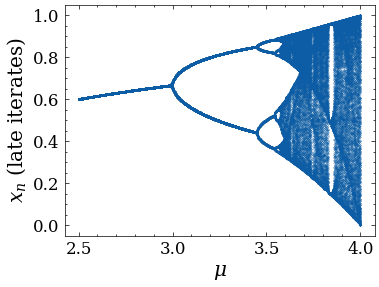

In [15]:
mus = np.linspace(2.5, 4.0, 800)
x = np.full_like(mus, 0.2)
out_m, out_x = [], []
for i in range(400):
    x = mus * x * (1 - x)
    if i > 200:
        out_m.append(mus.copy()); out_x.append(x.copy())

plt.plot(np.concatenate(out_m), np.concatenate(out_x), ".", ms=0.3)
plt.xlabel(r"$\mu$")
plt.ylabel(r"$x_n$ (late iterates)")
plt.show()

Order, cycles, then chaos through repeated **bifurcations** — all from multiplying by a parabola. Simple rules, complex behavior: the reason discrete dynamics deserve care (and the reason your simulations sometimes surprise you).

## 10. Case connection: the 2021 C hornet model, simplified

The Week 2 case (MCM 2021 C, Team 2101166) models the spread of the **Asian giant hornet** with a **yearly time-step difference equation**: the wasp's annual life cycle makes one year the natural step. Each nest produces new queens — a **Poisson random count** (more food and a larger growth rate $r$ mean more; competition, weighted by $\gamma$, means fewer) — and each queen founds a new nest.

Their aggregate version, dropping the geography, is exactly a yeast-style rule with noise:

$$N_t \sim \mathrm{Poisson}\!\left( \frac{r\,N_{t-1}}{1 + \gamma\,N_{t-1}} \right).$$

Simulate it (8 Monte Carlo replicates, 11 years, $N_0 = 3$ nests — the paper's own setup) and check their conclusion. (The paper's full model also tracks **where** nests are: each nest's fertility $Q_i \sim \mathrm{Poisson}(r E_i / (1+\gamma C_i))$ depends on its position: $E_i$ is **fixed by that location**, while $C_i$ **grows with time** as new nests are founded nearby.)

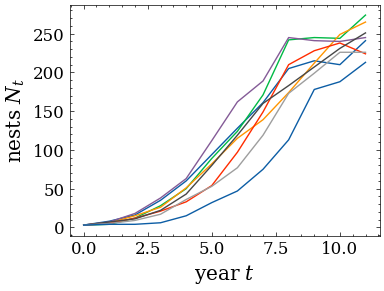

In [16]:
rng = np.random.default_rng(1)
r, gamma = 2.0, 0.004          # hyperparameters (calibrated, values rounded)
trials = []
for k in range(8):             # Monte Carlo replicates, as in the paper
    N = 3.0                    # three initial nests
    traj = [N]
    for t in range(11):        # eleven years, as in the paper
        N = max(rng.poisson(r * N / (1 + gamma * N)), 1)
        traj.append(N)
    trials.append(traj)

plt.plot(np.array(trials).T, lw=1)
plt.xlabel("year $t$")
plt.ylabel("nests $N_t$")
plt.show()

Growth starts fast (near-exponential) and bends down — the logistic shape. The paper **validates** exactly this: they fit the logistic curve to their simulated nest counts (MSE $0.076$) and conclude the inflection is still years away, so **control is urgent now**. Difference equation + Poisson noise + logistic benchmark — this week's toolkit, used to win an Outstanding prize.

## Practice exercises

**These are practice for yourself — they are not the graded assignments.** Problem sets are released separately on Blackboard, with due dates.

1. **Mortgage.** In section 6: find the month when the loan is fully paid. What monthly payment would pay it off in exactly 60 months?
2. **Equilibrium classification.** For $(r, b) = (0.9, 100)$, $(1.02, -500)$, $(-0.8, 40)$: find the EV via $a^* = b/(1-r)$, say whether it is stable using the $|r|$ criterion, and check by simulation.
3. **A third city.** Add Miami to the rental system with its own transition row/column of your choosing (rows must still sum to 1). Does the equilibrium still exist? Find it with the eigenvalue code.
4. **Hunter sensitivity.** In section 8: perturb the hunter start $(150, 200)$ by $\pm 1$. Make it quantitative: for each starting owl count from 145 to 155 (hawks fixed at 200), run the model and record which species dies out. Where exactly is the tipping point?
5. **Bifurcation location.** In section 9: zoom in on the bifurcation diagram between $\mu = 2.9$ and $3.1$ (use a finer $\mu$ grid) and locate the birth of the 2-cycle to two decimal places.
6. **Hornet control.** In section 10: lower $r$ to $1.5$ and raise $\gamma$ to $0.01$. What happens to the equilibrium? Now let WSDA remove a fixed number of nests each year (subtract $c$ in the update). How large must $c$ be to drive $N$ to extinction? — that is the paper's policy question.